# GNN-BERT Music Context Demo

This notebook runs inference on a real processed FMA track using:
- the leakage-safe FMA test manifest
- a saved real-data GNN-BERT Task 3 checkpoint
- the stored PyTorch Geometric audio graph
- the real FMA metadata text context and genre targets

The DEAM audio/valence-arousal manifests are available separately under `data/splits/deam/`; this demo keeps the prediction labels consistent with the FMA checkpoint.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import torch

ROOT = Path.cwd().resolve()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src").is_dir():
        ROOT = candidate
        break
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from fma_dataset import load_fma_label_names
from train import FusionTrainingModel

MANIFEST_ROOT = ROOT / "data" / "splits"
CHECKPOINT = ROOT / "checkpoints" / "expanded_fma" / "task3_epoch_1.pt"
print("Project root:", ROOT)
print("Checkpoint exists:", CHECKPOINT.exists())
print("Torch version:", torch.__version__)


C:\Users\rifat\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Project root: D:\425 project\gnn-bert-music-context
Checkpoint exists: True
Torch version: 2.14.0+cpu


In [2]:
# Load one real held-out FMA example and its stored graph/text context
manifest = json.loads((MANIFEST_ROOT / "test.json").read_text(encoding="utf-8"))
record = manifest[0]
labels = load_fma_label_names(MANIFEST_ROOT)
graph_path = ROOT / record["graph_path"]
graph = torch.load(graph_path, weights_only=False)
text_context = record["text_context"]
reference_tags = record.get("tags", [])

print("Track ID:", record["track_id"])
print("Graph:", graph_path)
print("Text context:", text_context)
print("Reference tags:", reference_tags)
print("Graph nodes:", graph.num_nodes)
print("Graph edges:", graph.edge_index.size(1))

Track ID: 001649
Graph: D:\425 project\gnn-bert-music-context\data\processed\graphs\001649.pt
Text context: artist: So Cow. album: Wackity Schmackity Doo. track: Inis Meain. genres: pop
Reference tags: ['pop']
Graph nodes: 11
Graph edges: 110


In [3]:
# Load the real trained Task 3 model and run graph/text fusion inference
model = FusionTrainingModel(task="task3", num_tags=len(labels))
model.load_state_dict(torch.load(CHECKPOINT, map_location="cpu"))
model.eval()

with torch.no_grad():
    graph_embedding, hidden_text = model.encode(graph, [text_context])
    tag_logits, valence_pred, arousal_pred = model.head(graph_embedding, hidden_text)

print("Text representation shape:", tuple(hidden_text.shape))
print("Graph representation shape:", tuple(graph_embedding.shape))
print("Tag logits shape:", tuple(tag_logits.shape))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text representation shape: (1, 28, 768)
Graph representation shape: (1, 128)
Tag logits shape: (1, 26)


In [4]:
# Decode predictions and compare them with the held-out record labels
probabilities = torch.sigmoid(tag_logits[0])
top_indices = torch.argsort(probabilities, descending=True)[:10].tolist()
predicted_tags = [labels[index] for index in top_indices if probabilities[index] >= 0.5]

print("Predicted tags:", predicted_tags or [labels[index] for index in top_indices[:5]])
print("Reference FMA tags:", reference_tags)
print(f"Predicted valence: {valence_pred[0, 0].item():.4f}")
print(f"Predicted arousal: {arousal_pred[0, 0].item():.4f}")
print("Note: this FMA checkpoint has no DEAM regression targets; use data/splits/deam for verified emotion labels.")

Predicted tags: ['field recordings', 'experimental', 'metal', 'psych-folk', 'drone', 'noise', 'international', 'hip-hop', 'folk', 'rock']
Reference FMA tags: ['pop']
Predicted valence: 0.1687
Predicted arousal: 0.3051
Note: this FMA checkpoint has no DEAM regression targets; use data/splits/deam for verified emotion labels.


C:\Users\rifat\AppData\Local\Temp\ipykernel_24728\3372285994.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


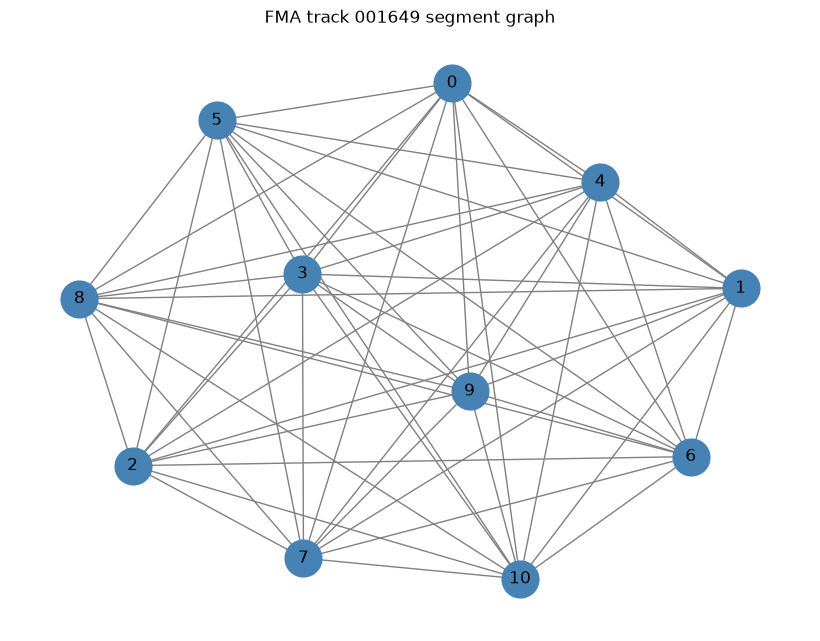

In [5]:
# Inspect the real graph structure
G = nx.Graph()
G.add_nodes_from(range(graph.num_nodes))
for source, target in graph.edge_index.t().tolist():
    if source != target:
        G.add_edge(source, target)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="steelblue", node_size=700, edge_color="gray")
plt.title(f"FMA track {record['track_id']} segment graph")
plt.tight_layout()
plt.show()

In [6]:
# Show the verified DEAM dataset is available for the emotion extension
DEAM_REPORT = ROOT / "data" / "splits" / "deam" / "alignment_report.json"
print(json.loads(DEAM_REPORT.read_text(encoding="utf-8")))

{'audio_root': 'D:\\425 project\\gnn-bert-music-context\\data\\raw\\deam\\audio', 'target_records': 1802, 'matched_audio_records': 1802, 'unmatched_audio_files': 0, 'metadata_records': 1802, 'splits': {'train': 1441, 'val': 180, 'test': 181}, 'pairing_rule': 'exact normalized numeric DEAM song_id to audio filename stem'}


## Summary

This demo uses real FMA graph data, real metadata text, and a saved real-data GNN-BERT checkpoint. DEAM audio and emotion targets are also downloaded and exactly paired in their own manifests, but are not mixed with FMA because their dataset IDs are unrelated.